# TFM — Sistema de Apoyo a la Clasificación FSE+
## 01b: Entendimiento de Datos — Análisis Técnico-Estadístico
---
### Objetivo
Este notebook complementa al EDA de negocio (`01_data_understanding.ipynb`). Aquí nos centramos exclusivamente en **medir, cuantificar y visualizar** las propiedades estadísticas del dataset crudo (`Dataset.csv`) para fundamentar las decisiones de preprocesamiento y modelado.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLOR_P, COLOR_NP = '#2ECC71', '#E74C3C'

from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/TFM - Master en IA y Ciencia de Datos/data/raw'
df = pd.read_csv(f'{DATA_PATH}/Dataset.csv', sep=';', dtype={'COD_EAN': str, 'ID_TARJETA': str}, low_memory=False)
df['ESTADO'] = df['ESTADO'].astype(str).str.strip().str.upper()
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado: 659,272 filas x 18 columnas


## 1. Schema: Tipos de Dato, Nulos y Cardinalidad

In [ ]:
schema = pd.DataFrame({
    'Tipo': df.dtypes,
    'No_Nulos': df.notnull().sum(),
    'Nulos': df.isnull().sum(),
    '%_Nulos': (df.isnull().mean() * 100).round(2),
    'Cardinalidad': df.nunique(),
    'Ejemplo': df.iloc[0]
})
display(schema)

,Tipo,No_Nulos,Nulos,%_Nulos,Cardinalidad,Ejemplo
NOMBRE_EMPRESA,object,659272,0,0.00,5,SUPERMERCADO1
ID_TARJETA,object,659272,0,0.00,2273,4295571159000021
COD_EAN,object,654908,4364,0.66,24773,8480024648853
ID_TICKETS,object,659272,0,0.00,25222,20251204177011975
DESCRIPCION_ARTICULO,object,659272,0,0.00,38827,YOGUR LIQUIDO 0% 0% CON FRESA
UNIDAD_MEDIDA,object,549727,109545,16.62,12,NaN
UNIDADES_ARTICULO,object,460996,198276,30.07,3897,1
GRUPO,int64,659272,0,0.00,2,1
ID_SECCION,float64,659271,1,0.00,70,5.0
SECCION,object,659271,1,0.00,103,Derivados lácteos


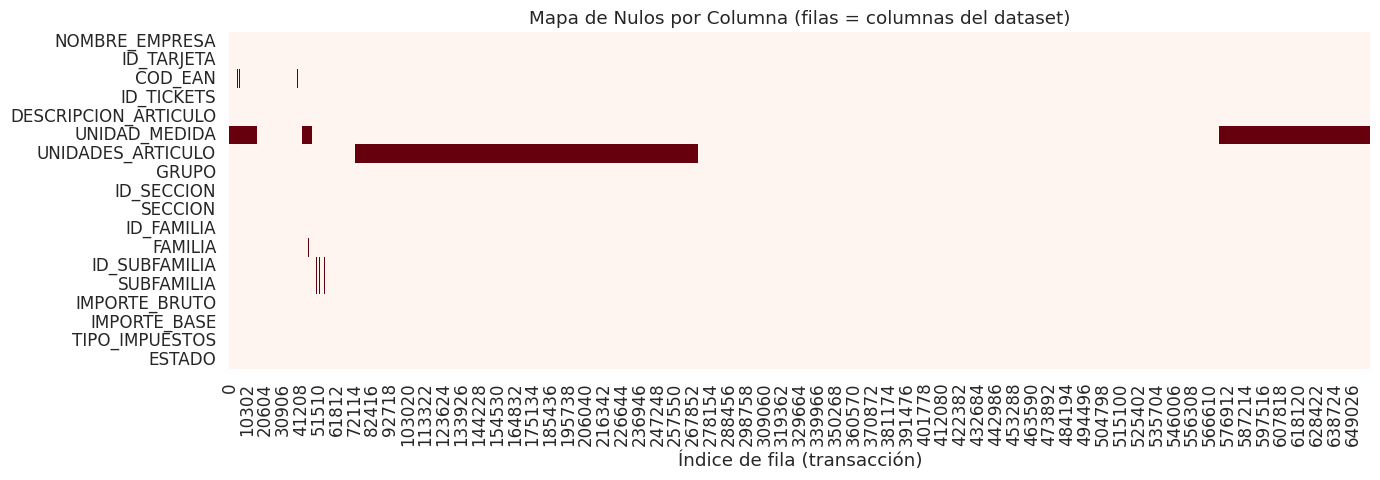

In [ ]:
# Mapa de calor de nulos
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df.isnull().T, cbar=False, cmap='Reds', yticklabels=True, ax=ax)
ax.set_title('Mapa de Nulos por Columna (filas = columnas del dataset)')
ax.set_xlabel('Índice de fila (transacción)')
plt.tight_layout()
plt.show()

## 2. Variable Target: Distribución de ESTADO

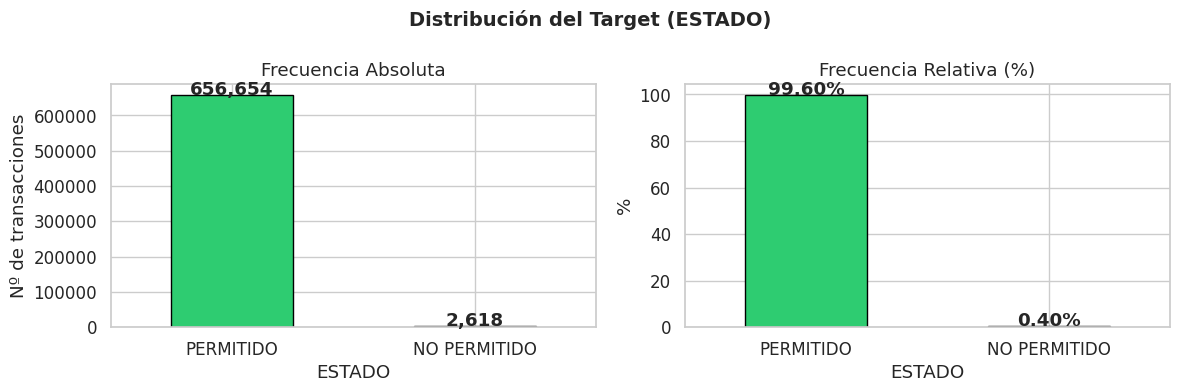


Ratio de desbalance: 251:1


In [ ]:
target_counts = df['ESTADO'].value_counts()
target_pct = df['ESTADO'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts.plot(kind='bar', color=[COLOR_P, COLOR_NP], edgecolor='black', ax=axes[0])
axes[0].set_title('Frecuencia Absoluta')
axes[0].set_ylabel('Nº de transacciones')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

target_pct.plot(kind='bar', color=[COLOR_P, COLOR_NP], edgecolor='black', ax=axes[1])
axes[1].set_title('Frecuencia Relativa (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(target_pct):
    axes[1].text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold')

plt.suptitle('Distribución del Target (ESTADO)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

ratio = target_counts.max() / target_counts.min()
print(f'\nRatio de desbalance: {ratio:.0f}:1')

## 3. Variables Numéricas: Estadísticos Descriptivos por ESTADO

In [ ]:
cols_num = ['IMPORTE_BRUTO', 'IMPORTE_BASE', 'UNIDADES_ARTICULO', 'TIPO_IMPUESTOS']
# Convertir comas decimales a punto si es necesario
for c in cols_num:
    if df[c].dtype == 'object':
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', '.'), errors='coerce')

display(df.groupby('ESTADO')[cols_num].describe().T)

ESTADO                   NO PERMITIDO      PERMITIDO
IMPORTE_BRUTO     count   2618.000000  656653.000000
                  mean       2.927368       4.244431
                  std        3.262992       6.171089
                  min      -10.980000    -249.000000
                  25%        1.430000       1.630000
                  50%        2.240000       2.700000
                  75%        3.450000       4.730000
                  max       61.640000     555.820000
IMPORTE_BASE      count   2618.000000  656654.000000
                  mean       2.873434       4.000557
                  std        3.040087       5.676799
                  min       -9.980000    -226.360000
                  25%        1.410000       1.580000
                  50%        2.240000       2.590000
                  75%        3.440000       4.500000
                  max       46.230000     455.210000
UNIDADES_ARTICULO count   2532.000000  458464.000000
                  mean       1.421011       1.690090
                  std        1.482041      22.426988
                  min       -1.000000     -60.000000
                  25%        1.000000       1.000000
                  50%        1.000000       1.000000
                  75%        2.000000       2.000000
                  max       20.000000    6774.000000
TIPO_IMPUESTOS    count   2618.000000  656654.000000
                  mean      10.603514       8.540137
                  std        3.874041       4.651623
                  min        0.000000       0.000000
                  25%       10.000000       4.000000
                  50%       10.000000      10.000000
                  75%       10.000000      10.000000
                  max       21.000000      21.000000

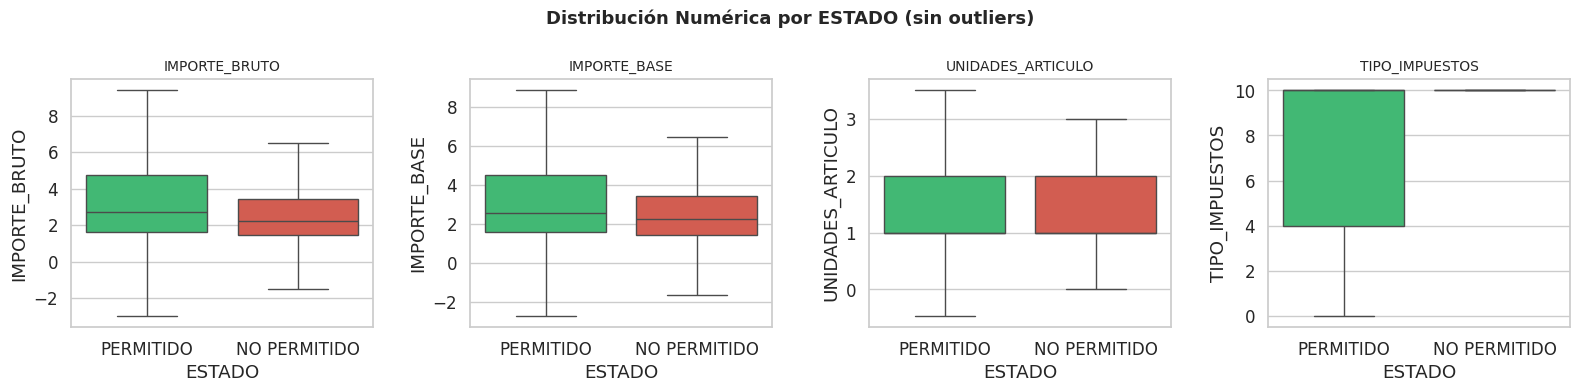

In [ ]:
# Boxplots comparativos por ESTADO
fig, axes = plt.subplots(1, len(cols_num), figsize=(16, 4), sharey=False)
for i, col in enumerate(cols_num):
    sns.boxplot(data=df, x='ESTADO', y=col, ax=axes[i],
                palette={'PERMITIDO': COLOR_P, 'NO PERMITIDO': COLOR_NP}, showfliers=False)
    axes[i].set_title(col, fontsize=10)
plt.suptitle('Distribución Numérica por ESTADO (sin outliers)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Análisis Textual: DESCRIPCION_ARTICULO

In [ ]:
df['desc_clean'] = df['DESCRIPCION_ARTICULO'].astype(str).str.strip().str.upper()
df['len_chars'] = df['desc_clean'].str.len()
df['len_tokens'] = df['desc_clean'].str.split().str.len()

print('--- Estadísticos de Longitud (caracteres) ---')
display(df.groupby('ESTADO')['len_chars'].describe().round(1))

print('\n--- Estadísticos de Longitud (tokens/palabras) ---')
display(df.groupby('ESTADO')['len_tokens'].describe().round(1))

--- Estadísticos de Longitud (caracteres) ---


,count,mean,std,min,25%,50%,75%,max
ESTADO,,,,,,,,
NO PERMITIDO,2618.0,36.5,12.0,11.0,29.0,36.0,43.0,127.0
PERMITIDO,656654.0,28.2,7.5,3.0,25.0,28.0,30.0,114.0



--- Estadísticos de Longitud (tokens/palabras) ---


,count,mean,std,min,25%,50%,75%,max
ESTADO,,,,,,,,
NO PERMITIDO,2618.0,6.2,2.2,1.0,5.0,6.0,7.0,20.0
PERMITIDO,656654.0,4.6,1.6,1.0,4.0,4.0,5.0,20.0


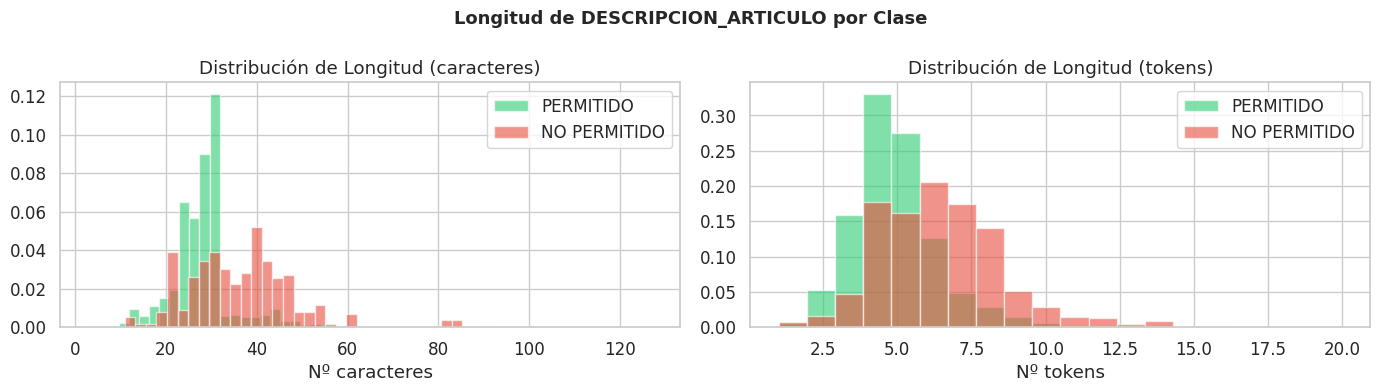

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for estado, color in [('PERMITIDO', COLOR_P), ('NO PERMITIDO', COLOR_NP)]:
    subset = df[df['ESTADO'] == estado]
    axes[0].hist(subset['len_chars'], bins=50, alpha=0.6, color=color, label=estado, density=True)
    axes[1].hist(subset['len_tokens'], bins=20, alpha=0.6, color=color, label=estado, density=True)

axes[0].set_title('Distribución de Longitud (caracteres)')
axes[0].set_xlabel('Nº caracteres')
axes[0].legend()
axes[1].set_title('Distribución de Longitud (tokens)')
axes[1].set_xlabel('Nº tokens')
axes[1].legend()
plt.suptitle('Longitud de DESCRIPCION_ARTICULO por Clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Indicadores de ruido textual
total = len(df)
muy_cortos = (df['len_chars'] < 10).sum()
con_puntos = df['desc_clean'].str.contains(r'\.', regex=True, na=False).sum()
con_barras = df['desc_clean'].str.contains(r'/', na=False).sum()
con_numeros = df['desc_clean'].str.contains(r'\d', regex=True, na=False).sum()
desc_unicas = df['desc_clean'].nunique()

ruido_df = pd.DataFrame({
    'Indicador': ['Descripciones < 10 chars', 'Con puntos (abreviatura)',
                  'Con barras /', 'Con dígitos', 'Descripciones únicas'],
    'Cantidad': [muy_cortos, con_puntos, con_barras, con_numeros, desc_unicas],
    '% del total': [f'{x/total*100:.2f}%' for x in [muy_cortos, con_puntos, con_barras, con_numeros, desc_unicas]]
})
display(ruido_df)

,Indicador,Cantidad,% del total
0,Descripciones < 10 chars,2439,0.37%
1,Con puntos (abreviatura),152571,23.14%
2,Con barras /,51452,7.80%
3,Con dígitos,512601,77.75%
4,Descripciones únicas,38581,5.85%


## 5. Cobertura y Fiabilidad del COD_EAN

In [ ]:
ean_nulos = df['COD_EAN'].isnull().sum()
ean_total = len(df)
ean_unicos = df['COD_EAN'].nunique()

# EANs estándar tienen 8 o 13 dígitos
df['ean_standard'] = df['COD_EAN'].astype(str).str.match(r'^\d{8}$|^\d{13}$')
ean_std_count = df['ean_standard'].sum()
ean_internal = ean_total - ean_nulos - ean_std_count

print(f'EANs nulos: {ean_nulos:,} ({ean_nulos/ean_total*100:.2f}%)')
print(f'EANs estándar (8/13 dígitos): {ean_std_count:,} ({ean_std_count/ean_total*100:.2f}%)')
print(f'EANs internos/irregulares: {ean_internal:,} ({ean_internal/ean_total*100:.2f}%)')
print(f'EANs únicos: {ean_unicos:,}')

# EANs contradictorios (mismo EAN, distinto ESTADO)
ean_conflict = df.groupby('COD_EAN')['ESTADO'].nunique()
ean_conflict_n = (ean_conflict > 1).sum()
print(f'\n⚠️ EANs con etiqueta contradictoria: {ean_conflict_n:,}')

EANs nulos: 4,364 (0.66%)
EANs estándar (8/13 dígitos): 562,965 (85.39%)
EANs internos/irregulares: 91,943 (13.95%)
EANs únicos: 24,773

⚠️ EANs con etiqueta contradictoria: 127


## 6. Taxonomía: Concentración por SECCION, FAMILIA y SUBFAMILIA

In [ ]:
for nivel in ['SECCION', 'FAMILIA', 'SUBFAMILIA']:
    print(f'\n--- {nivel} ---')
    print(f'  Valores únicos: {df[nivel].nunique()}')
    # Tasa de NO PERMITIDO por categoría
    tasa_np = df.groupby(nivel)['ESTADO'].apply(lambda x: (x == 'NO PERMITIDO').mean() * 100)
    top_np = tasa_np[tasa_np > 0].sort_values(ascending=False).head(10)
    if len(top_np) > 0:
        print(f'  Top categorías con mayor tasa NO PERMITIDO:')
        for cat, pct in top_np.items():
            print(f'    {cat}: {pct:.1f}%')


--- SECCION ---
  Valores únicos: 103
  Top categorías con mayor tasa NO PERMITIDO:
    AUTOMOVIL: 100.0%
    Bollería: 100.0%
    Especialidades Navidad: 100.0%
    CASA-HOGAR: 100.0%
    EMBALAJES ECOLOGICOS: 100.0%
    No alimentación: 100.0%
    MOSTRADOR PLATOS PREPARADOS: 100.0%
    Helados: 100.0%
    PLATOS PREPARADOS: 100.0%
    PLATOS PREPARADOS L.S.: 100.0%

--- FAMILIA ---
  Valores únicos: 1573
  Top categorías con mayor tasa NO PERMITIDO:
    ADORNOS: 100.0%
    ARTESANAS /PAJA: 100.0%
    Aguas: 100.0%
    Accesorios y utiles de perfume: 100.0%
    Bolsas: 100.0%
    Base pasta: 100.0%
    Ambientadores: 100.0%
    BARQUILLOS: 100.0%
    BERLINAS: 100.0%
    BASICAS: 100.0%

--- SUBFAMILIA ---
  Valores únicos: 2469
  Top categorías con mayor tasa NO PERMITIDO:
    ADORNOS: 100.0%
    APERITIVOS: 100.0%
    ARTESANAS /PAJA: 100.0%
    Aditivos para lavado: 100.0%
    Accesorios y útiles perfumería: 100.0%
    ELABORADOS PROTEINA VEGETAL: 100.0%
    ELIXIRES BUCALES: 100

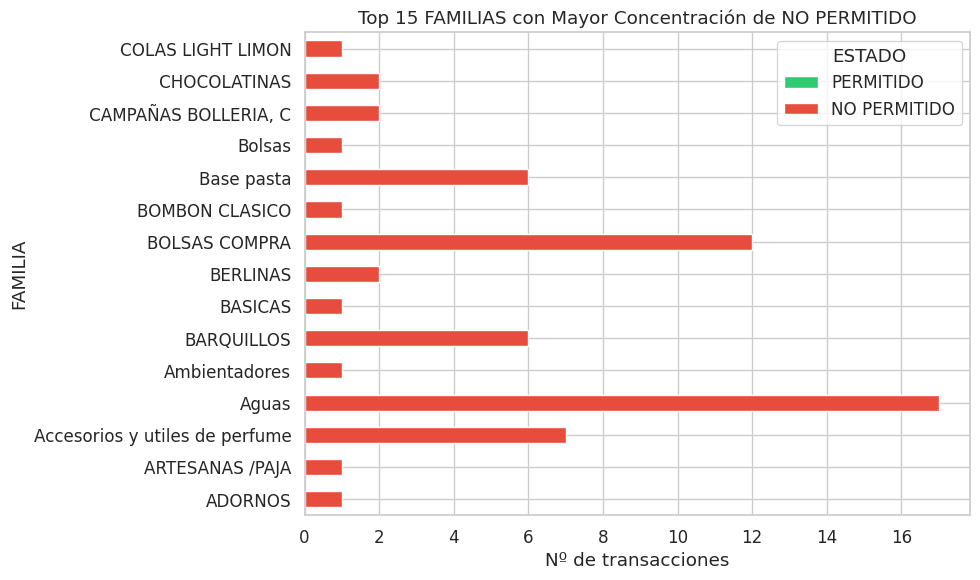

In [ ]:
# Heatmap de concentración: FAMILIA vs ESTADO
cross = pd.crosstab(df['FAMILIA'], df['ESTADO'])
cross['tasa_np'] = cross.get('NO PERMITIDO', 0) / cross.sum(axis=1) * 100
top_familias = cross.nlargest(15, 'tasa_np')[['PERMITIDO', 'NO PERMITIDO']]

fig, ax = plt.subplots(figsize=(10, 6))
top_familias.plot(kind='barh', stacked=True, color=[COLOR_P, COLOR_NP], ax=ax)
ax.set_title('Top 15 FAMILIAS con Mayor Concentración de NO PERMITIDO')
ax.set_xlabel('Nº de transacciones')
plt.tight_layout()
plt.show()

## 7. Distribución por NOMBRE_EMPRESA

,total,no_permitido,desc_unicas,subfam_unicas,tasa_np_%
NOMBRE_EMPRESA,,,,,
SUPERMERCADO4,510588,124,11936,931,0.02
SUPERMERCADO5,87661,2272,13293,890,2.59
SUPERMERCADO1,41806,202,5617,425,0.48
SUPERMERCADO3,17995,4,7674,319,0.02
SUPERMERCADO2,1222,16,374,145,1.31


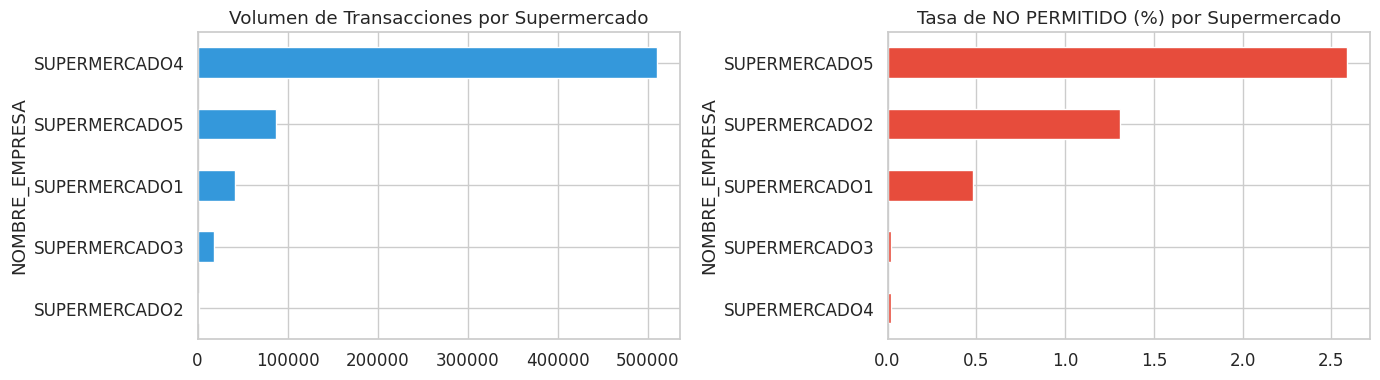

In [ ]:
empresa_stats = df.groupby('NOMBRE_EMPRESA').agg(
    total=('ESTADO', 'count'),
    no_permitido=('ESTADO', lambda x: (x == 'NO PERMITIDO').sum()),
    desc_unicas=('DESCRIPCION_ARTICULO', 'nunique'),
    subfam_unicas=('SUBFAMILIA', 'nunique')
)
empresa_stats['tasa_np_%'] = (empresa_stats['no_permitido'] / empresa_stats['total'] * 100).round(2)
display(empresa_stats.sort_values('total', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
empresa_stats['total'].sort_values().plot(kind='barh', color='#3498DB', ax=axes[0])
axes[0].set_title('Volumen de Transacciones por Supermercado')
empresa_stats['tasa_np_%'].sort_values().plot(kind='barh', color=COLOR_NP, ax=axes[1])
axes[1].set_title('Tasa de NO PERMITIDO (%) por Supermercado')
plt.tight_layout()
plt.show()

## 8. Top Tokens Discriminantes de la Clase NO PERMITIDO

In [ ]:
from collections import Counter

tokens_np = Counter()
tokens_p = Counter()
for _, row in df[['desc_clean', 'ESTADO']].iterrows():
    toks = str(row['desc_clean']).split()
    if row['ESTADO'] == 'NO PERMITIDO':
        tokens_np.update(toks)
    else:
        tokens_p.update(toks)

# Ratio de discriminación: frecuencia relativa en NP vs P
total_np = sum(tokens_np.values())
total_p = sum(tokens_p.values())

disc_scores = {}
for token in tokens_np:
    freq_np = tokens_np[token] / total_np
    freq_p = tokens_p.get(token, 0.5) / total_p  # Suavizado Laplace
    disc_scores[token] = freq_np / freq_p

top_disc = sorted(disc_scores.items(), key=lambda x: x[1], reverse=True)[:20]
top_df = pd.DataFrame(top_disc, columns=['Token', 'Score Discriminante'])
top_df['Frecuencia en NP'] = top_df['Token'].map(tokens_np)
display(top_df)

,Token,Score Discriminante,Frecuencia en NP
0,JQ,17457.933064,47
1,405G.,17086.487679,46
2,360G.,15600.706142,42
3,NUMERO,14486.369989,39
4,UNO,14486.369989,39
5,ANONIMO,12629.143067,34
6,TUNDRA,12257.697683,33
7,PIZZA&SALSA,10771.916146,29
8,TOFFEE,10771.916146,29
9,410G.,10029.025377,27


## 9. Duplicados Exactos y Conflictos de Etiquetado

In [ ]:
# Filas completamente duplicadas
n_dup_total = df.duplicated().sum()
n_dup_desc = df.duplicated(subset=['DESCRIPCION_ARTICULO']).sum()
print(f'Filas 100% duplicadas: {n_dup_total:,}')
print(f'Filas con DESCRIPCION_ARTICULO repetida: {n_dup_desc:,} ({n_dup_desc/len(df)*100:.1f}%)')

# Conflictos: misma descripción, distinto ESTADO
desc_states = df.groupby('desc_clean')['ESTADO'].nunique()
n_conflict = (desc_states > 1).sum()
print(f'\n⚠️ Descripciones con etiquetado contradictorio: {n_conflict:,}')

if n_conflict > 0:
    conflict_descs = desc_states[desc_states > 1].index[:5]
    print('\nEjemplos de conflicto:')
    display(df[df['desc_clean'].isin(conflict_descs)][['desc_clean', 'ESTADO', 'NOMBRE_EMPRESA']].drop_duplicates())

Filas 100% duplicadas: 969
Filas con DESCRIPCION_ARTICULO repetida: 620,445 (94.1%)

⚠️ Descripciones con etiquetado contradictorio: 34

Ejemplos de conflicto:


,desc_clean,ESTADO,NOMBRE_EMPRESA
61030,BAGELS CLASICO NEW YORK B.300G,NO PERMITIDO,SUPERMERCADO4
66801,BAGUETTE PRECOCIDA CRF 2X150G,NO PERMITIDO,SUPERMERCADO4
77109,BAGUETTE PRECOCIDA CRF 2X150G,PERMITIDO,SUPERMERCADO4
85046,BAGELS CLASICO NEW YORK B.300G,PERMITIDO,SUPERMERCADO4
573337,BARRITA CEREAL CAOCROC AUCHAN < PK 6 138 G,NO PERMITIDO,SUPERMERCADO5
573358,BARRA CEREAL CROUSTY CHOCO/LEC AUCHAN < 126 G,NO PERMITIDO,SUPERMERCADO5
573382,BARRA CEREAL CROUSTY CHOCO NEG AUCHAN < 6 UDS ...,NO PERMITIDO,SUPERMERCADO5
586925,BARRITA CEREAL CAOCROC AUCHAN < PK 6 138 G,PERMITIDO,SUPERMERCADO5
587057,BARRA CEREAL CROUSTY CHOCO NEG AUCHAN < 6 UDS ...,PERMITIDO,SUPERMERCADO5
587122,BARRA CEREAL CROUSTY CHOCO/LEC AUCHAN < 126 G,PERMITIDO,SUPERMERCADO5


## 10. Correlaciones Numéricas

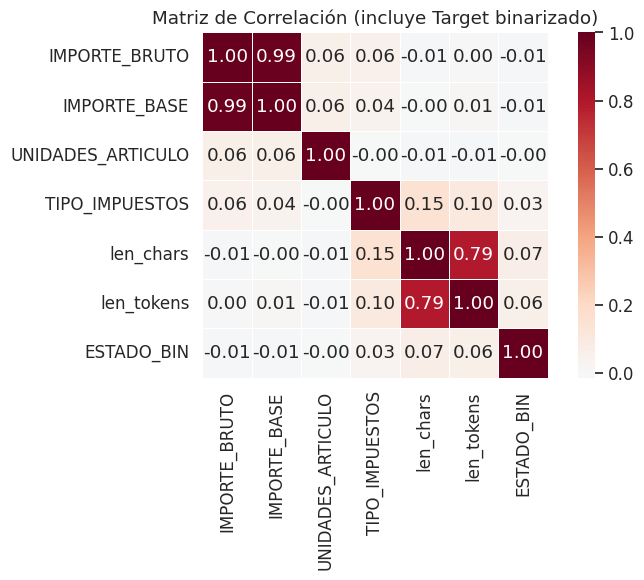


Correlación con ESTADO_BIN (NO PERMITIDO = 1):
len_chars            0.069680
len_tokens           0.064690
TIPO_IMPUESTOS       0.027903
UNIDADES_ARTICULO   -0.000889
IMPORTE_BASE        -0.012504
IMPORTE_BRUTO       -0.013441


In [ ]:
df['ESTADO_BIN'] = (df['ESTADO'] == 'NO PERMITIDO').astype(int)
cols_corr = cols_num + ['len_chars', 'len_tokens', 'ESTADO_BIN']
corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlación (incluye Target binarizado)')
plt.tight_layout()
plt.show()

print('\nCorrelación con ESTADO_BIN (NO PERMITIDO = 1):')
print(corr_matrix['ESTADO_BIN'].drop('ESTADO_BIN').sort_values(ascending=False).to_string())

## 11. Resumen Ejecutivo Técnico
Este análisis estadístico confirma los siguientes hechos medibles:
1. **Desbalance extremo** ratificado numéricamente.
2. **Las variables numéricas** (precios, unidades) tienen **baja correlación** con el target, validando la decisión de entrenar exclusivamente con texto.
3. **El ruido textual** (abreviaturas, truncamientos) afecta a un porcentaje significativo de las descripciones, exigiendo N-gramas de caracteres.
4. **Los EANs** no son 100% fiables (internos/irregulares) y presentan contradicciones.
5. **La taxonomía** (`SUBFAMILIA`) concentra reglas de negocio duras explotables determinísticamente.
6. **Los conflictos de etiquetado** requieren aislamiento antes del entrenamiento.

---
**Siguiente paso:** `02_data_preparation.ipynb` (Depuración, des-duplicación y extracción del Diccionario Maestro).